In [13]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
raw_data_train = pd.read_csv("../housing-data/train.csv").drop("Id", axis=1) # id is not needed.
raw_data_test = pd.read_csv("../housing-data/test.csv").drop("Id", axis=1) # id is not needed.

### Data Preprocessing

In [3]:
## First step: reaplce all NaNs with something. 
## It seems like all NaN values are in non-numeric columns, so we can probably replace it with "None"

train_noNAN = raw_data_train.replace(to_replace=pd.NA, value="None")
test_noNAN = raw_data_test.replace(to_replace=pd.NA, value="None")

# Get non-numeric features to dummy code (one hot encode)
non_numeric_features = train_noNAN.select_dtypes(exclude=['number']).columns.tolist()

train_noNAN = pd.get_dummies(train_noNAN, columns=non_numeric_features)
test_noNAN = pd.get_dummies(test_noNAN, columns=non_numeric_features)

In [4]:
num_features = len(train_noNAN.T)
num_samples = len(train_noNAN)

X = train_noNAN.drop(columns=["SalePrice"])
y = train_noNAN["SalePrice"]

# Split into training and validation sets. 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# No y_test because the data set is from kaggle. We will need to get a validation set. 
# Get test data here

## Model Training

In [17]:
params = {
    'objective': 'reg:squarederror',
    'max_depth': 10,
    'learning_rate': 0.1,
    'n_estimators': 500,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
}

In [18]:
# Create model with parameters and train. 
depths = np.arange(1, 11, 1)
rmse_list = []
r2_list = []

rmse = 0.0
r2 = 0.0

for depth in depths:
    params['max_depth'] = depth

    # Train Model
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred = model.predict(X_val)

    # Evaluate model performance
    rmse = np.sqrt(mean_squared_error(y_val, y_pred)) # Use RMSE, it actually gives us an idea of how off our average prediction was in dollars. 
    rmse_list.append(rmse)
    r2 = r2_score(y_val, y_pred)
    r2_list.append(r2)

## Model accuracy evaluation

[0.9009149074554443, 0.9191856980323792, 0.9182843565940857, 0.9222257137298584, 0.9191367030143738, 0.9164998531341553, 0.914242148399353, 0.913339376449585, 0.9071682691574097, 0.9072678089141846]
[np.float64(27568.37260340189), np.float64(24897.2274761669), np.float64(25035.68908578312), np.float64(24424.45332039184), np.float64(24904.774803238033), np.float64(25307.578627754967), np.float64(25647.42731737435), np.float64(25782.075013466234), np.float64(26684.261128987626), np.float64(26669.94713155615)]


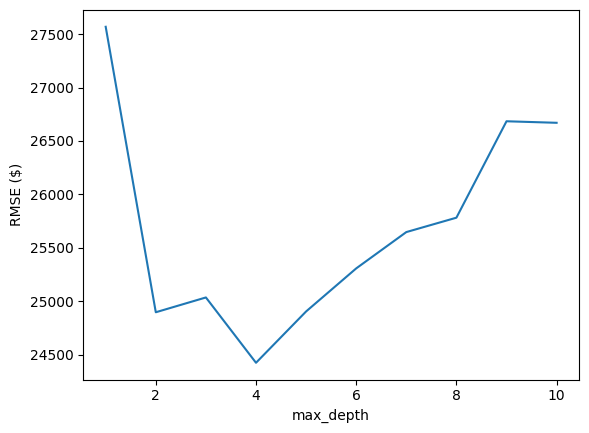

In [23]:
print(r2_list)
print(rmse_list)

plt.plot(depths, rmse_list)
plt.ylabel("RMSE ($)")
plt.xlabel("max_depth")
plt.show()
# print(f"Root Mean Squared Error: {rmse:.2f}")
# print(f"R-squared: {r2:.2f}")

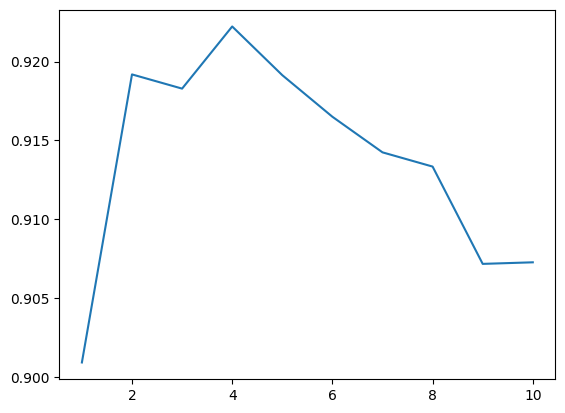

In [22]:
plt.plot(depths, r2_list)
plt.show()

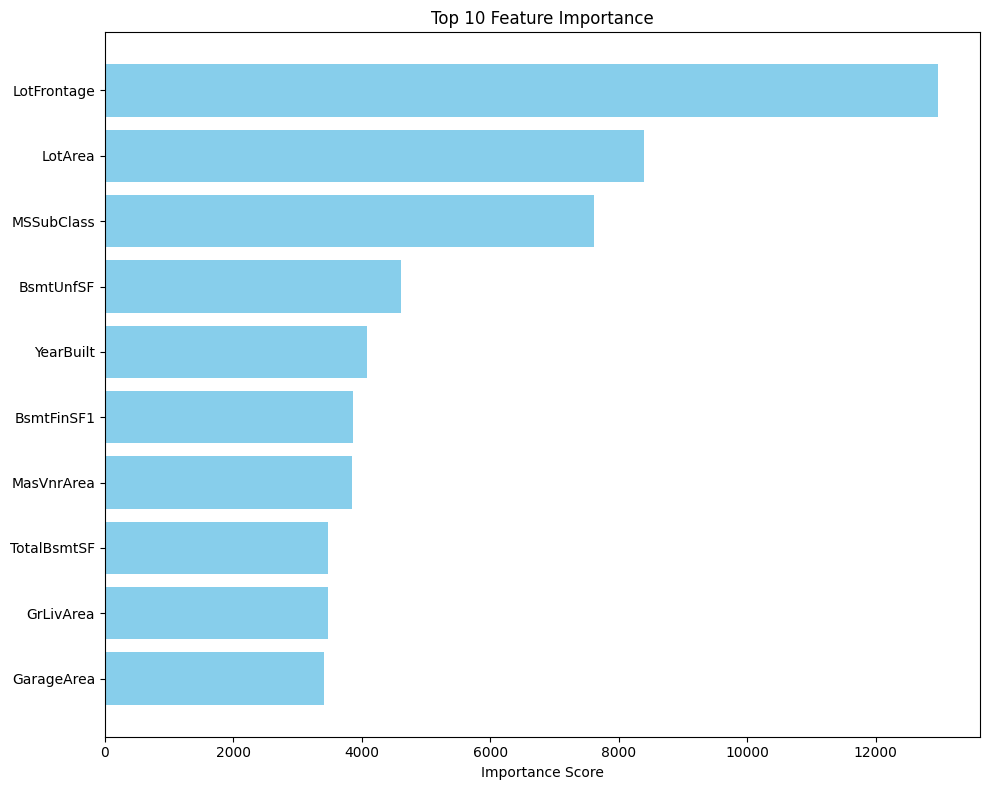

In [ ]:
importance = model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 10
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()